In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
temp = pd.read_csv("average-monthly-surface-temperature.csv")
co2 = pd.read_csv("owid-co2-data.csv")
precip = pd.read_csv("average-precipitation-per-year.csv")

print("Temperature shape:", temp.shape)
print("CO2 shape:", co2.shape)
print("Precipitation shape:", precip.shape)

Temperature shape: (220242, 4)
CO2 shape: (50411, 79)
Precipitation shape: (16770, 4)


In [3]:
#temperature data months grouped into years
temp["Day"] = pd.to_datetime(temp["Day"])
temp["year"] = temp["Day"].dt.year
temp = temp.groupby(["Entity", "year"])["Monthly average"].mean().reset_index()
temp = temp.rename(columns={"Entity": "country", "Monthly average": "avg_temperature"})

print("Temperature cleaned:", temp.shape)
print(temp.head())

Temperature cleaned: (18531, 3)
       country  year  avg_temperature
0  Afghanistan  1940        11.327695
1  Afghanistan  1941        13.324756
2  Afghanistan  1942        12.885449
3  Afghanistan  1943        11.524769
4  Afghanistan  1944        12.143665


In [4]:
#removed redundant colunns from co2 data
co2 = co2[["country", "year", "co2", "co2_per_capita", "methane", "population"]]

print("CO2 cleaned:", co2.shape)
print(co2.head())

CO2 cleaned: (50411, 6)
       country  year  co2  co2_per_capita  methane   population
0  Afghanistan  1750  NaN             NaN      NaN    2802560.0
1       Africa  1750  NaN             NaN      NaN   79382032.0
2      Andorra  1750  NaN             NaN      NaN       2221.0
3   Antarctica  1750  NaN             NaN      NaN          NaN
4         Asia  1750  0.0             0.0      NaN  498699232.0


In [5]:
#rename them to country, year, and precipitation_mm
precip = precip.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Annual precipitation": "precipitation_mm"
})
precip = precip[["country", "year", "precipitation_mm"]]

print("Precipitation cleaned:", precip.shape)
print(precip.head())

Precipitation cleaned: (16770, 3)
       country  year  precipitation_mm
0  Afghanistan  1940         217.67816
1  Afghanistan  1941         196.80933
2  Afghanistan  1942         300.08908
3  Afghanistan  1943         345.60892
4  Afghanistan  1944         324.44350


In [6]:
#merge
df = pd.merge(temp, co2, on=["country", "year"], how="inner")
df = pd.merge(df, precip, on=["country", "year"], how="inner")

print("Merged shape:", df.shape)
print(df.head())

Merged shape: (15810, 8)
       country  year  avg_temperature  co2  co2_per_capita  methane  \
0  Afghanistan  1940        11.327695  NaN             NaN    6.814   
1  Afghanistan  1941        13.324756  NaN             NaN    6.937   
2  Afghanistan  1942        12.885449  NaN             NaN    7.061   
3  Afghanistan  1943        11.524769  NaN             NaN    7.186   
4  Afghanistan  1944        12.143665  NaN             NaN    7.312   

   population  precipitation_mm  
0   6468510.0         217.67816  
1   6528377.0         196.80933  
2   6608815.0         300.08908  
3   6710138.0         345.60892  
4   6813016.0         324.44350  


In [7]:
#handle missing
df = df.dropna()
df.to_csv("merged_climate_data.csv", index=False) #new merged dataset

print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Year range:", df["year"].min(), "to", df["year"].max())
print("Countries:", df["country"].nunique())
print("Saved successfully!")

Final shape: (14064, 8)
Columns: ['country', 'year', 'avg_temperature', 'co2', 'co2_per_capita', 'methane', 'population', 'precipitation_mm']
Year range: 1940 to 2024
Countries: 179
Saved successfully!


In [8]:

df = pd.read_csv("merged_climate_data.csv")
df = df[df["country"] != "World"]
print(df.shape)
print(df.head())


(13979, 8)
       country  year  avg_temperature    co2  co2_per_capita  methane  \
0  Afghanistan  1949        10.509593  0.015           0.002    7.729   
1  Afghanistan  1950        10.231125  0.084           0.011    7.879   
2  Afghanistan  1951        11.242811  0.092           0.012    7.973   
3  Afghanistan  1952        11.292934  0.092           0.011    8.073   
4  Afghanistan  1953        11.445144  0.106           0.013    8.186   

   population  precipitation_mm  
0   7356890.0          405.3034  
1   7776180.0          347.0461  
2   7879343.0          457.9805  
3   7987784.0          382.8329  
4   8096703.0          569.5969  


In [9]:
print(df.describe())

               year  avg_temperature           co2  co2_per_capita  \
count  13979.000000     13979.000000  13979.000000    13979.000000   
mean    1984.567208        18.153119    115.398901        4.157501   
std       23.527375         8.266990    555.738361        7.885903   
min     1940.000000        -6.767322      0.000000        0.000000   
25%     1965.000000        10.645849      1.068000        0.312500   
50%     1985.000000        21.781278      7.353000        1.512000   
75%     2005.000000        25.050044     45.666000        5.514000   
max     2024.000000        29.794220  12289.037000      364.791000   

           methane    population  precipitation_mm  
count  13979.00000  1.397900e+04      13979.000000  
mean      38.68155  2.895687e+07       1170.702334  
std      109.99394  1.091731e+08        828.456714  
min        0.00700  1.375000e+04          3.292084  
25%        2.77450  2.060990e+06        623.486400  
50%        9.34000  6.082987e+06        995.170600 

In [10]:
print("Countries:", df["country"].nunique())
print("Years from:",df["year"].min(),"to", df["year"].max())
print("missing:",df.isnull().sum())

Countries: 178
Years from: 1940 to 2024
missing: country             0
year                0
avg_temperature     0
co2                 0
co2_per_capita      0
methane             0
population          0
precipitation_mm    0
dtype: int64


<h1 align="center">Temperature Graphs<h1>


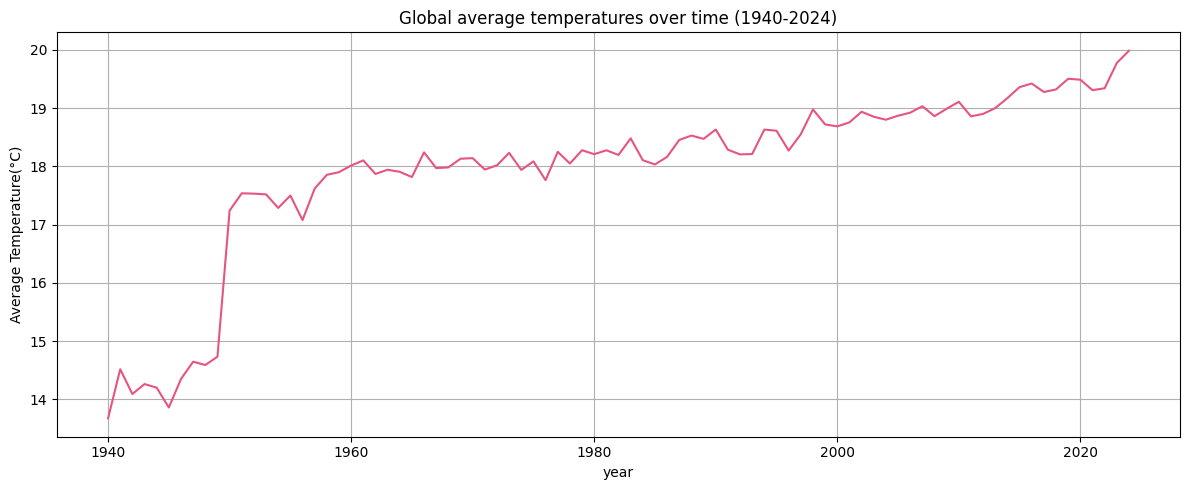

In [11]:
#Graph of temperature over time
global_temp=df.groupby("year")["avg_temperature"].mean()
plt.figure(figsize=(12,5))
plt.plot(global_temp.index,global_temp.values,color="#E75480")
plt.title("Global average temperatures over time (1940-2024)")
plt.xlabel("year")
plt.ylabel("Average Temperature(°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

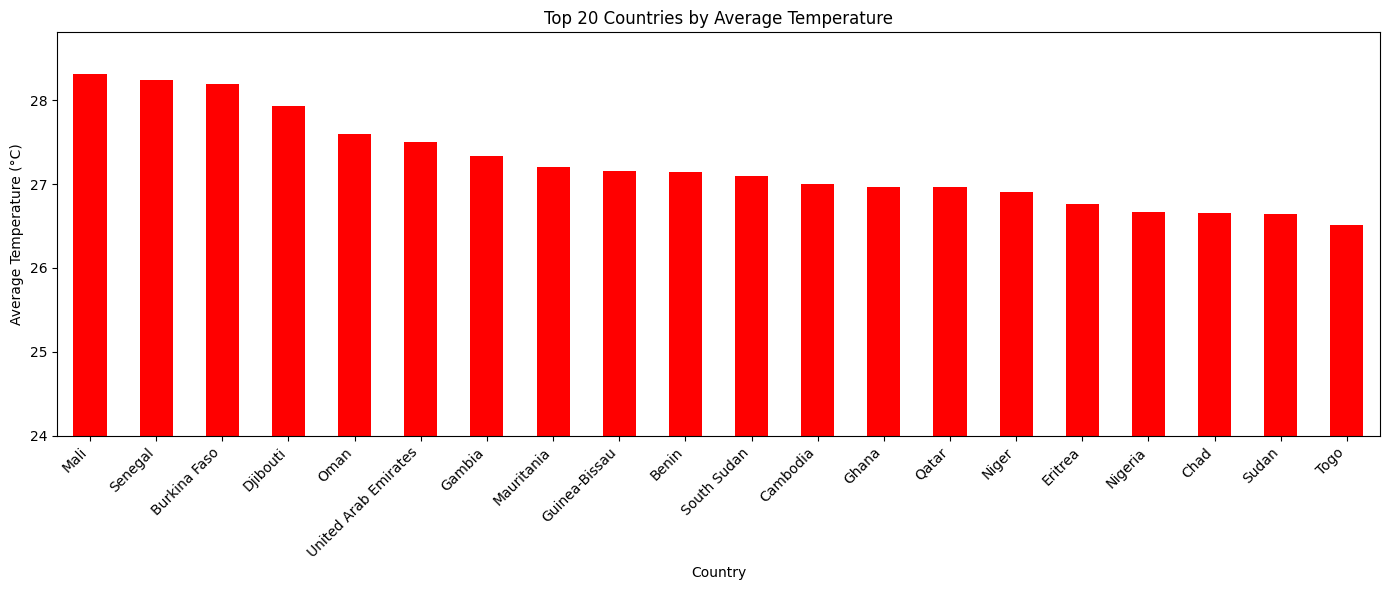

In [12]:
top_temp=df.groupby("country")["avg_temperature"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(14,6))
top_temp.plot(kind="bar", color="red")
plt.title("Top 20 Countries by Average Temperature")
plt.xlabel("Country")
plt.ylabel("Average Temperature (°C)")
plt.ylim(24, top_temp.max() + 0.5)  # this line fixed the bar charts that looked the same size

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

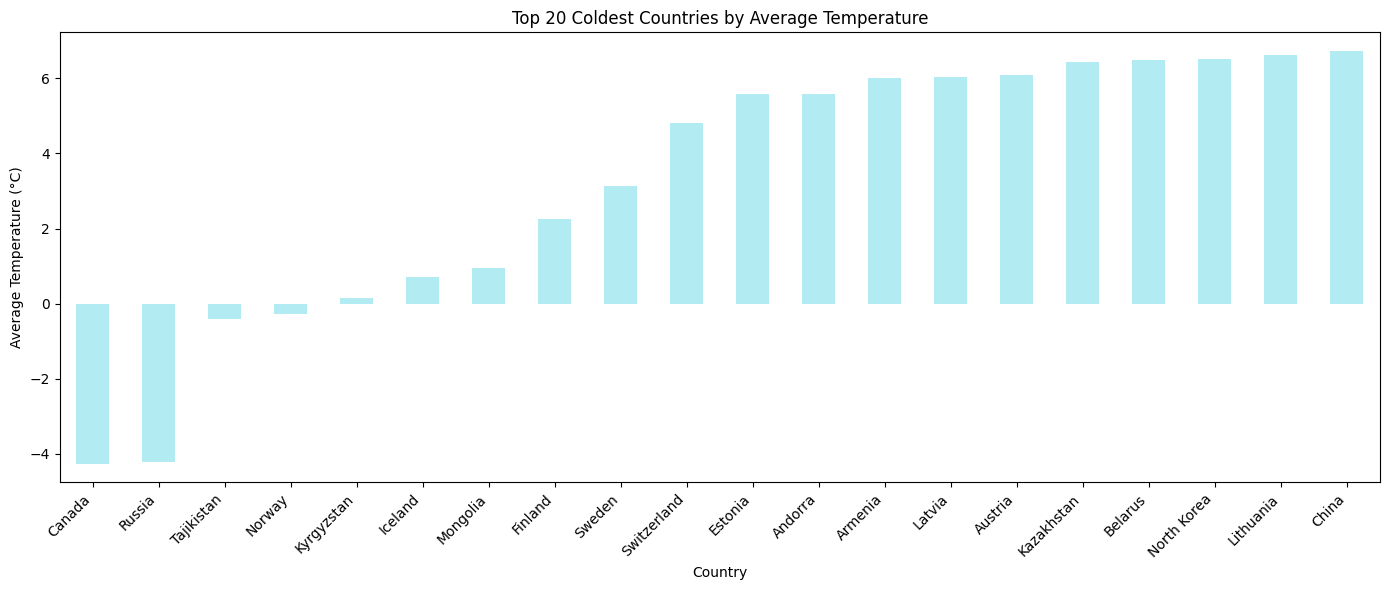

In [13]:
bottom_temp = df.groupby("country")["avg_temperature"].mean().sort_values(ascending=True).head(20)
plt.figure(figsize=(14, 6))
bottom_temp.plot(kind="bar", color="#B3EBF2")
plt.title("Top 20 Coldest Countries by Average Temperature")
plt.xlabel("Country")
plt.ylabel("Average Temperature (°C)")
plt.ylim(bottom_temp.min() - 0.5, bottom_temp.max() + 0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<h1 align="center">CO2 Graphs<h1>


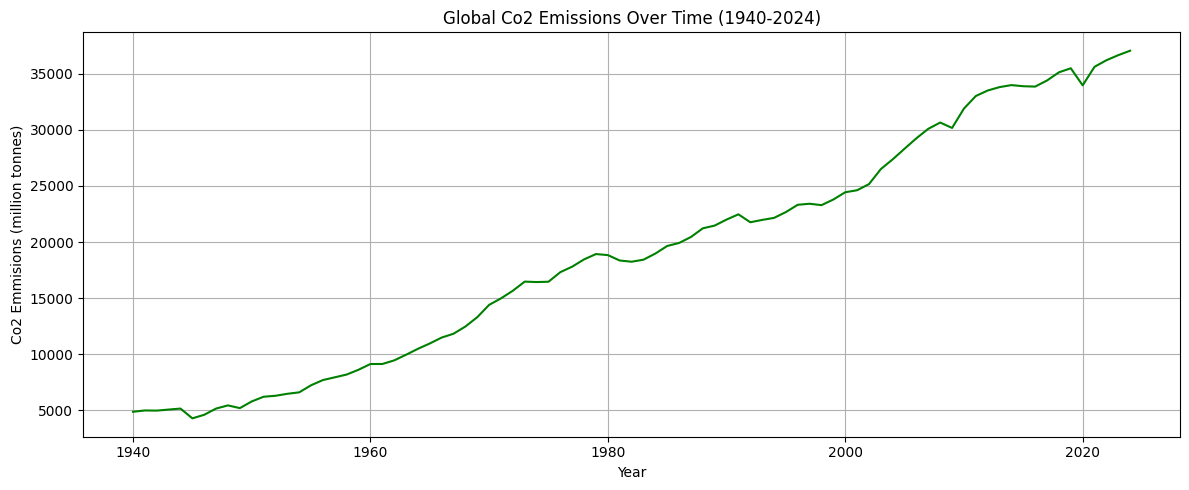

In [14]:
#Graph of total CO2 emissions over time
global_co2=df.groupby("year")["co2"].sum()

plt.figure(figsize=(12,5))
plt.plot(global_co2.index,global_co2.values,color="green")
plt.title("Global Co2 Emissions Over Time (1940-2024)")
plt.xlabel("Year")
plt.ylabel("Co2 Emmisions (million tonnes)")
plt.grid(True)
plt.tight_layout()
plt.show()

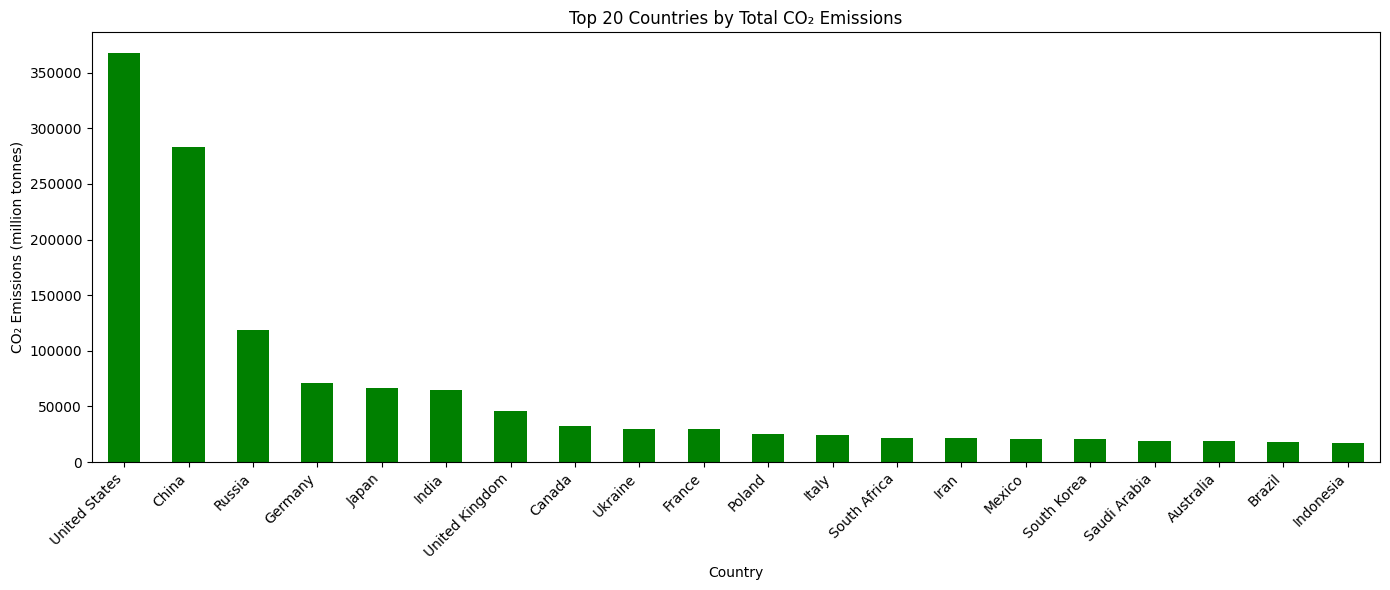

In [15]:
top_co2 = df.groupby("country")["co2"].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(14, 6))
top_co2.plot(kind="bar", color="green")
plt.title("Top 20 Countries by Total CO₂ Emissions")
plt.xlabel("Country")
plt.ylabel("CO₂ Emissions (million tonnes)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

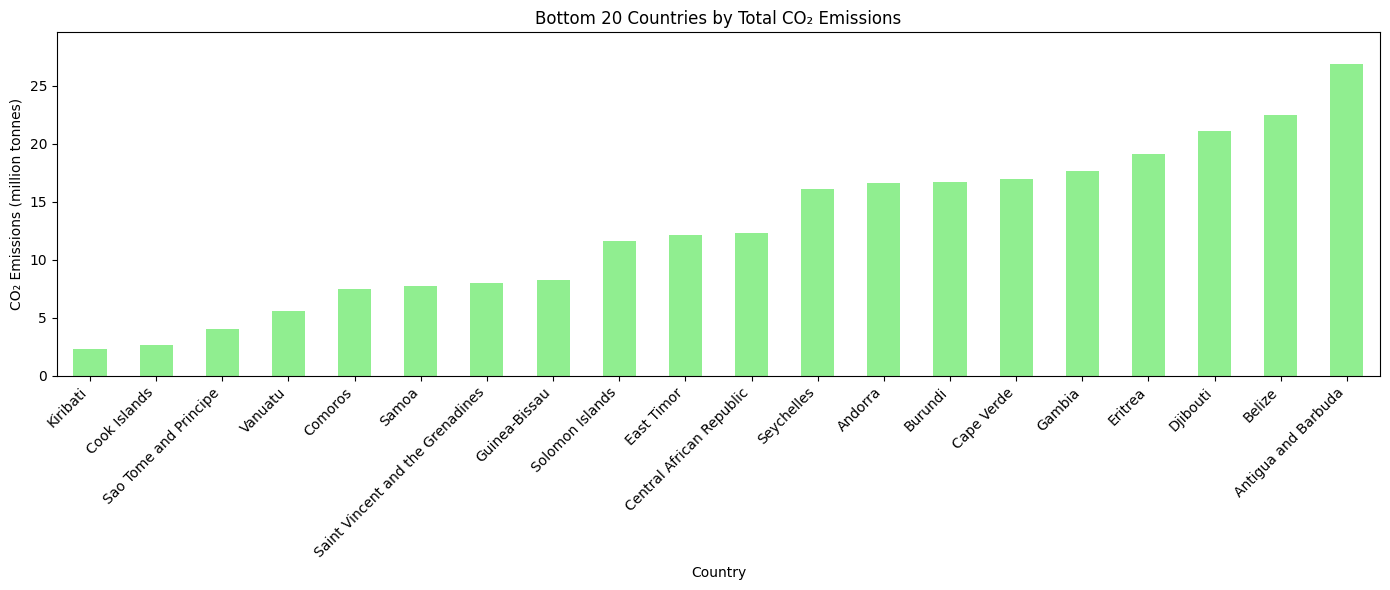

In [16]:
bottom_co2 = df.groupby("country")["co2"].sum().sort_values(ascending=True).head(20)
plt.figure(figsize=(14, 6))
bottom_co2.plot(kind="bar", color="lightgreen")
plt.title("Bottom 20 Countries by Total CO₂ Emissions")
plt.xlabel("Country")
plt.ylabel("CO₂ Emissions (million tonnes)")
plt.ylim(0, bottom_co2.max() * 1.1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<h1 align="center">Precipitation Graphs<h1>


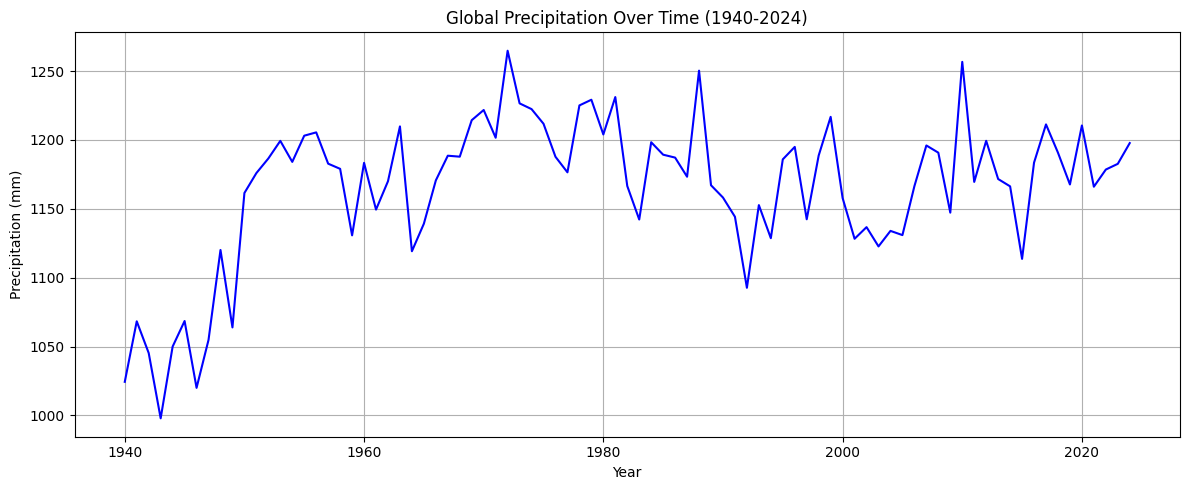

In [17]:
global_precip=df.groupby("year")["precipitation_mm"].mean()
plt.figure(figsize=(12,5))
plt.plot(global_precip.index,global_precip.values,color="blue")
plt.title("Global Precipitation Over Time (1940-2024)")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

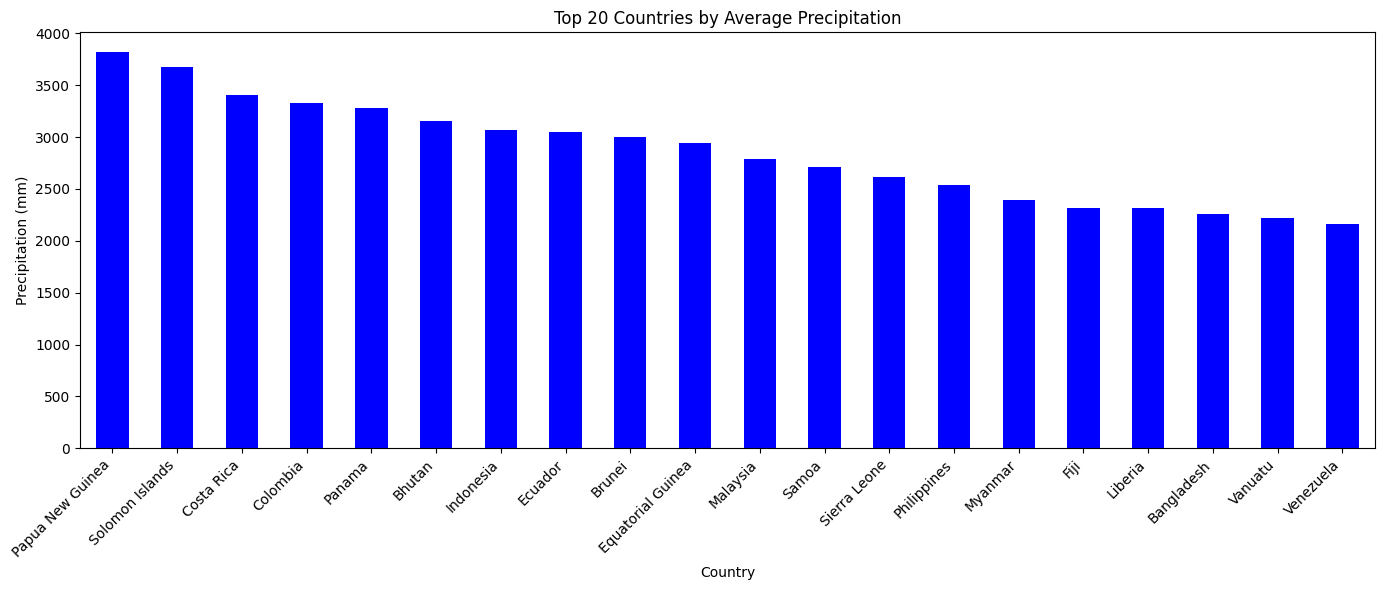

In [18]:
top_precip = df.groupby("country")["precipitation_mm"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(14, 6))
top_precip.plot(kind="bar", color="blue")
plt.title("Top 20 Countries by Average Precipitation")
plt.xlabel("Country")
plt.ylabel("Precipitation (mm)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

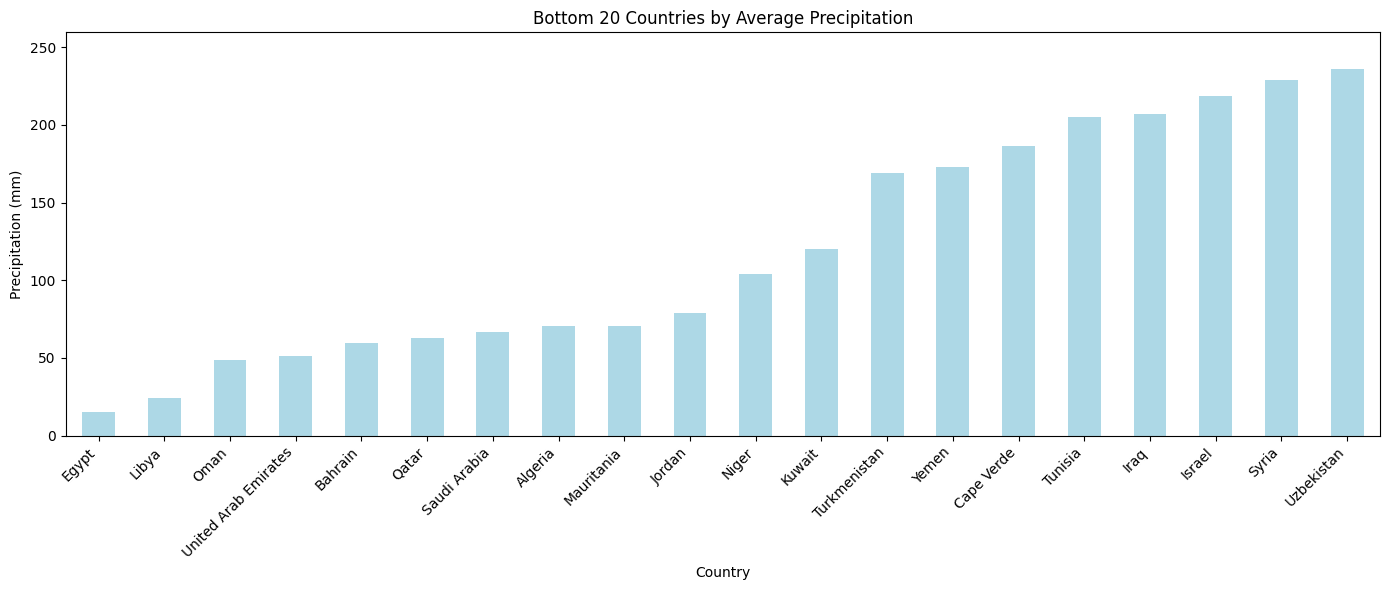

In [19]:
bottom_precip = df.groupby("country")["precipitation_mm"].mean().sort_values(ascending=True).head(20)
plt.figure(figsize=(14, 6))
bottom_precip.plot(kind="bar", color="lightblue")
plt.title("Bottom 20 Countries by Average Precipitation")
plt.xlabel("Country")
plt.ylabel("Precipitation (mm)")
plt.ylim(0, bottom_precip.max() * 1.1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

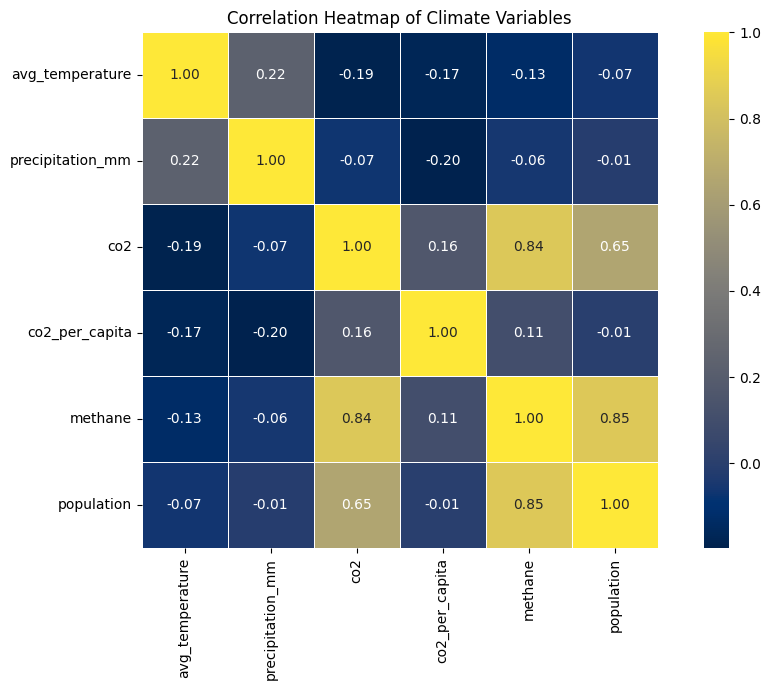

In [20]:
plt.figure(figsize=(10, 7))
corr = df[["avg_temperature", "precipitation_mm", "co2", "co2_per_capita", "methane", "population"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="cividis", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Climate Variables")
plt.tight_layout()
plt.show()

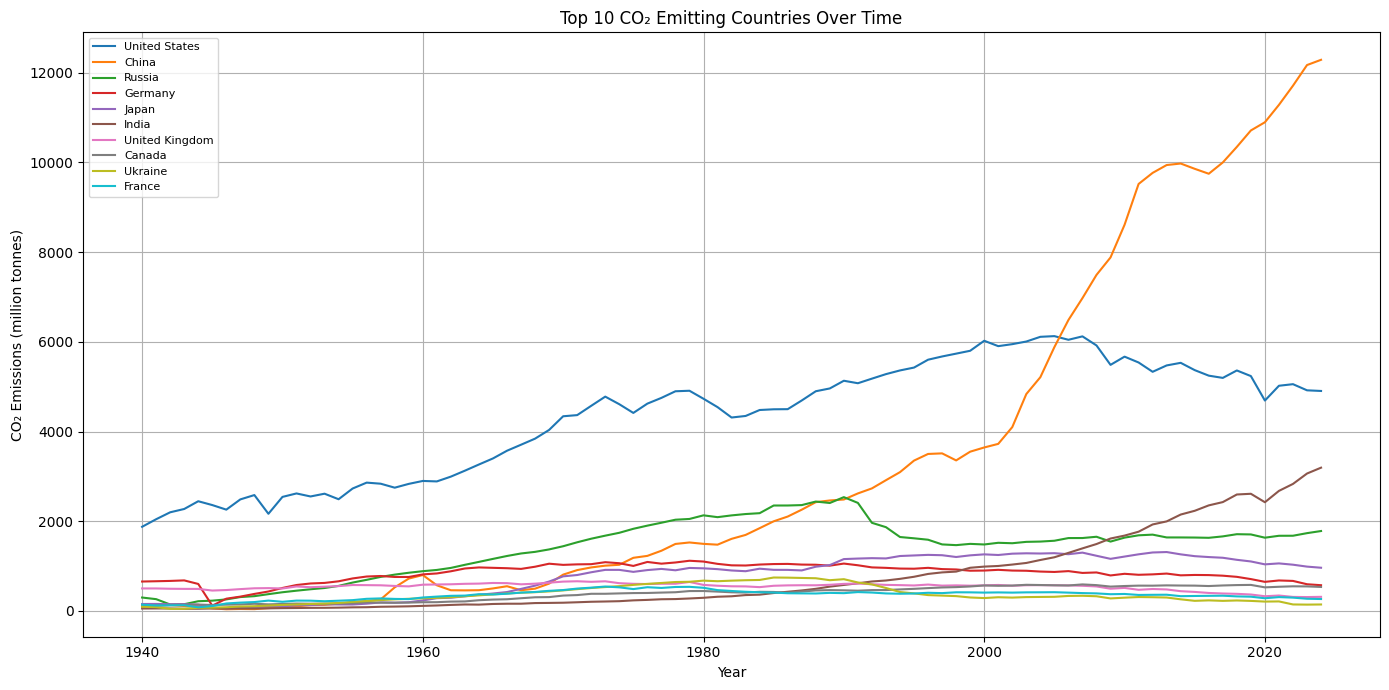

In [21]:
top10_countries = df.groupby("country")["co2"].sum().sort_values(ascending=False).head(10).index

plt.figure(figsize=(14, 7))
for country in top10_countries:
    country_data = df[df["country"] == country]
    plt.plot(country_data["year"], country_data["co2"], label=country)

plt.title("Top 10 CO₂ Emitting Countries Over Time")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (million tonnes)")
plt.legend(loc="upper left", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
continent_map = {
    "Africa": ["Nigeria", "South Africa", "Egypt", "Algeria", "Ethiopia", "Kenya", "Ghana", "Tanzania", "Morocco", "Angola", "Cameroon", "Ivory Coast", "Niger", "Mali", "Senegal", "Chad", "Tunisia", "Libya", "Sudan", "Zimbabwe", "Mozambique", "Uganda", "Madagascar", "Zambia", "Guinea", "Rwanda", "Benin", "Togo", "Sierra Leone", "Eritrea", "Djibouti", "Burkina Faso", "South Sudan", "Guinea-Bissau", "Gabon", "Botswana", "Mauritania", "Namibia", "Malawi", "Congo", "Lesotho", "Gambia"],
    "Asia": ["China", "India", "Japan", "South Korea", "Indonesia", "Iran", "Saudi Arabia", "Thailand", "Pakistan", "Bangladesh", "Vietnam", "Malaysia", "Iraq", "Kazakhstan", "Uzbekistan", "Qatar", "United Arab Emirates", "Kuwait", "Oman", "Syria", "Yemen", "Myanmar", "Sri Lanka", "Nepal", "Cambodia", "Afghanistan", "Mongolia", "Turkmenistan", "Azerbaijan", "Georgia", "Armenia", "Tajikistan", "Kyrgyzstan"],
    "Europe": ["Russia", "Germany", "United Kingdom", "France", "Italy", "Spain", "Poland", "Ukraine", "Netherlands", "Belgium", "Czech Republic", "Romania", "Sweden", "Norway", "Finland", "Denmark", "Switzerland", "Austria", "Portugal", "Hungary", "Belarus", "Greece", "Bulgaria", "Slovakia", "Croatia", "Lithuania", "Latvia", "Estonia", "Slovenia", "Luxembourg", "Iceland", "Serbia", "Bosnia and Herzegovina", "Albania", "Moldova", "North Macedonia"],
    "North America": ["United States", "Canada", "Mexico", "Cuba", "Guatemala", "Honduras", "El Salvador", "Nicaragua", "Costa Rica", "Panama", "Jamaica", "Trinidad and Tobago", "Haiti", "Dominican Republic"],
    "South America": ["Brazil", "Argentina", "Chile", "Colombia", "Venezuela", "Peru", "Ecuador", "Bolivia", "Paraguay", "Uruguay", "Guyana", "Suriname"],
    "Oceania": ["Australia", "New Zealand", "Papua New Guinea", "Fiji"]
}

def get_continent(country):
    for continent, countries in continent_map.items():
        if country in countries:
            return continent
    return "Other"

df["continent"] = df["country"].apply(get_continent)
print(df["continent"].value_counts())

continent
Africa           3005
Europe           2960
Other            2846
Asia             2668
North America    1180
South America    1000
Oceania           320
Name: count, dtype: int64


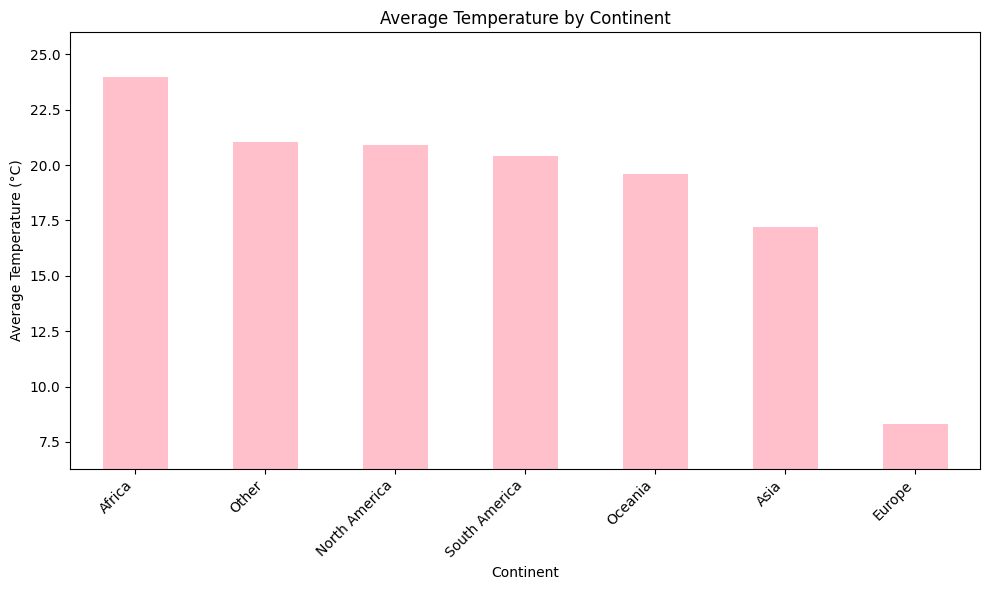

In [23]:
continent_temp = df.groupby("continent")["avg_temperature"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
continent_temp.plot(kind="bar", color="pink")
plt.title("Average Temperature by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Temperature (°C)")
plt.ylim(continent_temp.min() - 2, continent_temp.max() + 2)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

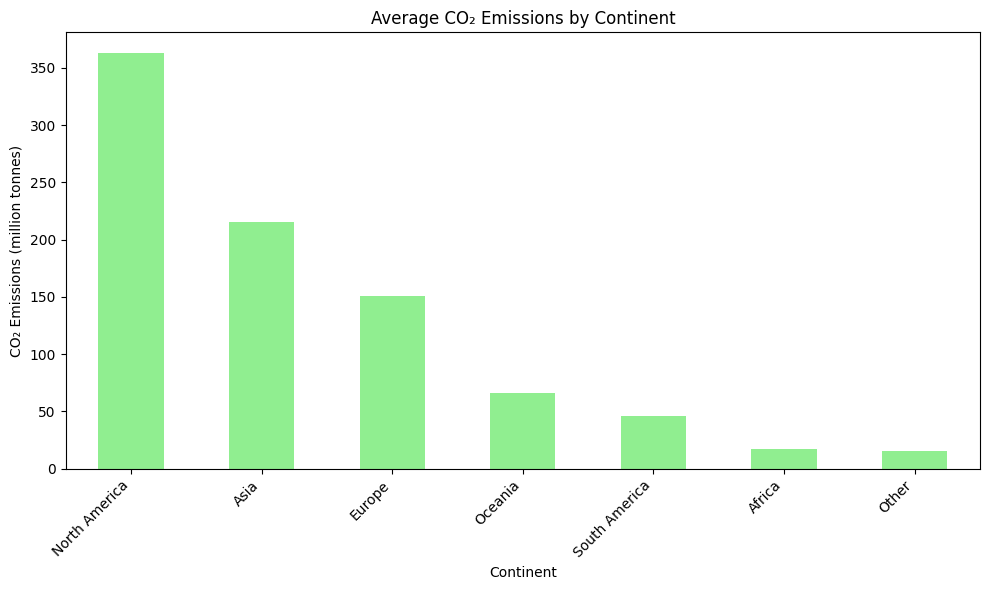

In [24]:
continent_co2 = df.groupby("continent")["co2"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
continent_co2.plot(kind="bar", color="lightgreen")
plt.title("Average CO₂ Emissions by Continent")
plt.xlabel("Continent")
plt.ylabel("CO₂ Emissions (million tonnes)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

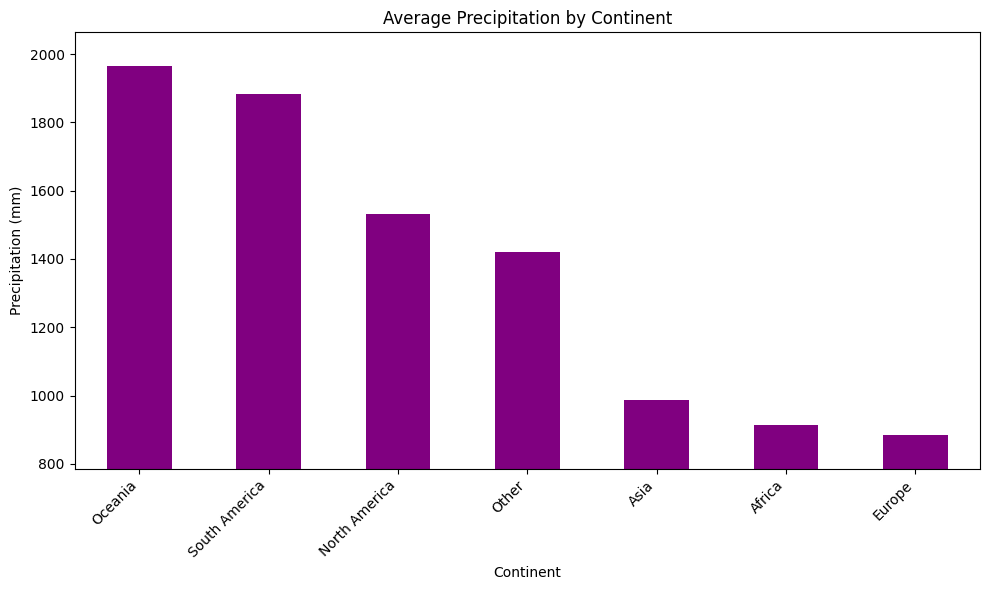

In [25]:
continent_precip = df.groupby("continent")["precipitation_mm"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
continent_precip.plot(kind="bar", color="purple")
plt.title("Average Precipitation by Continent")
plt.xlabel("Continent")
plt.ylabel("Precipitation (mm)")
plt.ylim(continent_precip.min() - 100, continent_precip.max() + 100)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

LINEAR REGRESSION

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [27]:
# one-hot encode country as geographic feature
country_dummies = pd.get_dummies(df["country"], prefix="country", drop_first=True)

X = pd.concat([
    df[["year", "co2", "co2_per_capita", "methane"]],
    country_dummies
], axis=1)

y_temp = df["avg_temperature"]
y_precip = df["precipitation_mm"]

print("Predictors shape:", X.shape)
print("Features count:", X.shape[1])


Predictors shape: (13979, 181)
Features count: 181


In [28]:
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X, y_temp, test_size=0.2, random_state=42)
X_train_precip, X_test_precip, y_train_precip, y_test_precip = train_test_split(X, y_precip, test_size=0.2, random_state=42)

print("Training rows:", X_train_temp.shape[0])
print("Testing rows:", X_test_temp.shape[0])

Training rows: 11183
Testing rows: 2796


In [29]:
#Train linear regression for temperature
lr_temp = LinearRegression()
lr_temp.fit(X_train_temp, y_train_temp)
print("model trained")
print("\nCoefficients:")
for feature, coef in zip(X.columns, lr_temp.coef_):
    print(f"  {feature}: {coef:.6f}")
print(f"intercept: {lr_temp.intercept_:.4f}")

model trained

Coefficients:
  year: 0.022848
  co2: 0.000110
  co2_per_capita: -0.006646
  methane: -0.001286
  country_Albania: 0.363709
  country_Algeria: 11.040978
  country_Andorra: -6.917812
  country_Angola: 9.775687
  country_Antigua and Barbuda: 13.956193
  country_Argentina: 2.626478
  country_Armenia: -5.999310
  country_Australia: 10.241965
  country_Austria: -5.820811
  country_Azerbaijan: -0.238155
  country_Bahamas: 13.289667
  country_Bahrain: 13.978027
  country_Bangladesh: 13.197048
  country_Belarus: -5.409750
  country_Belgium: -2.095617
  country_Belize: 13.031380
  country_Benin: 15.069141
  country_Bhutan: -4.203564
  country_Bolivia: 7.797541
  country_Bosnia and Herzegovina: -2.241901
  country_Botswana: 9.581881
  country_Brazil: 13.010551
  country_Brunei: 14.016676
  country_Bulgaria: -1.012880
  country_Burkina Faso: 16.093877
  country_Burundi: 8.050864
  country_Cambodia: 14.870961
  country_Cameroon: 12.139679
  country_Canada: -16.056639
  country_Cape 

In [30]:
y_pred_temp=lr_temp.predict(X_test_temp)

# errorcalculation
mae_temp = mean_absolute_error(y_test_temp, y_pred_temp)
rmse_temp=np.sqrt(mean_squared_error(y_test_temp,y_pred_temp))
r2_temp = lr_temp.score(X_test_temp, y_test_temp)

print("linear regression performance for temperature:")
print(f"MAE: {mae_temp:.4f}")
print(f"RMSE:{rmse_temp:.4f}")
print(f"R²: {r2_temp:.4f}")

linear regression performance for temperature:
MAE: 0.3915
RMSE:0.5292
R²: 0.9959


In [31]:
lr_precip=LinearRegression()
lr_precip.fit(X_train_precip, y_train_precip)
y_pred_precip=lr_precip.predict(X_test_precip)

mae_precip=mean_absolute_error(y_test_precip,y_pred_precip)
rmse_precip=np.sqrt(mean_squared_error(y_test_precip,y_pred_precip))
r2_precip = lr_precip.score(X_test_precip, y_test_precip)
print("linear regression performance for precipitation:")
print(f"MAE: {mae_precip:.4f}")
print(f"RMSE:{rmse_precip:.4f}")        
print(f"R²: {r2_precip:.4f}")

linear regression performance for precipitation:
MAE: 129.0187
RMSE:196.0313
R²: 0.9412


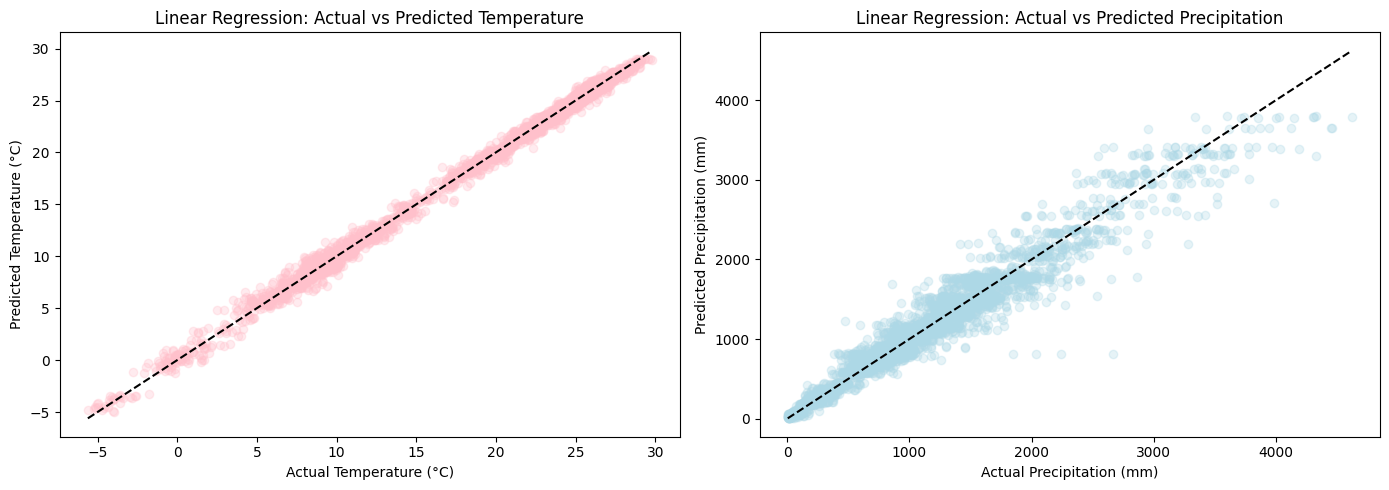

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# temperature: actual vs predicted
axes[0].scatter(y_test_temp, y_pred_temp, alpha=0.3, color="pink")
axes[0].plot([y_test_temp.min(), y_test_temp.max()], [y_test_temp.min(), y_test_temp.max()], color="black", linestyle="--")
axes[0].set_title("Linear Regression: Actual vs Predicted Temperature")
axes[0].set_xlabel("Actual Temperature (°C)")
axes[0].set_ylabel("Predicted Temperature (°C)")

# precipitation: actual vs predicted
axes[1].scatter(y_test_precip, y_pred_precip, alpha=0.3, color="lightblue")
axes[1].plot([y_test_precip.min(), y_test_precip.max()], [y_test_precip.min(), y_test_precip.max()], color="black", linestyle="--")
axes[1].set_title("Linear Regression: Actual vs Predicted Precipitation")
axes[1].set_xlabel("Actual Precipitation (mm)")
axes[1].set_ylabel("Predicted Precipitation (mm)")

plt.tight_layout()
plt.show()

RANDOM FOREST

In [33]:
# train random forest for temperature
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train_temp, y_train_temp)
y_pred_rf_temp = rf_temp.predict(X_test_temp)

mae_rf_temp = mean_absolute_error(y_test_temp, y_pred_rf_temp)
rmse_rf_temp = np.sqrt(mean_squared_error(y_test_temp, y_pred_rf_temp))
r2_rf_temp = rf_temp.score(X_test_temp, y_test_temp)

print("Random Forest performance for temperature:")
print(f"MAE:  {mae_rf_temp:.4f}")
print(f"RMSE: {rmse_rf_temp:.4f}")
print(f"R²:   {r2_rf_temp:.4f}")

Random Forest performance for temperature:
MAE:  0.5356
RMSE: 1.0113
R²:   0.9849


In [34]:
# train random forest for precipitation
rf_precip = RandomForestRegressor(n_estimators=100, random_state=42)
rf_precip.fit(X_train_precip, y_train_precip)
y_pred_rf_precip = rf_precip.predict(X_test_precip)

mae_rf_precip = mean_absolute_error(y_test_precip, y_pred_rf_precip)
rmse_rf_precip = np.sqrt(mean_squared_error(y_test_precip, y_pred_rf_precip))
r2_rf_precip = rf_precip.score(X_test_precip, y_test_precip)

print("Random Forest performance for precipitation:")
print(f"MAE:  {mae_rf_precip:.4f}")
print(f"RMSE: {rmse_rf_precip:.4f}")
print(f"R²:   {r2_rf_precip:.4f}")

Random Forest performance for precipitation:
MAE:  128.8502
RMSE: 196.7636
R²:   0.9408


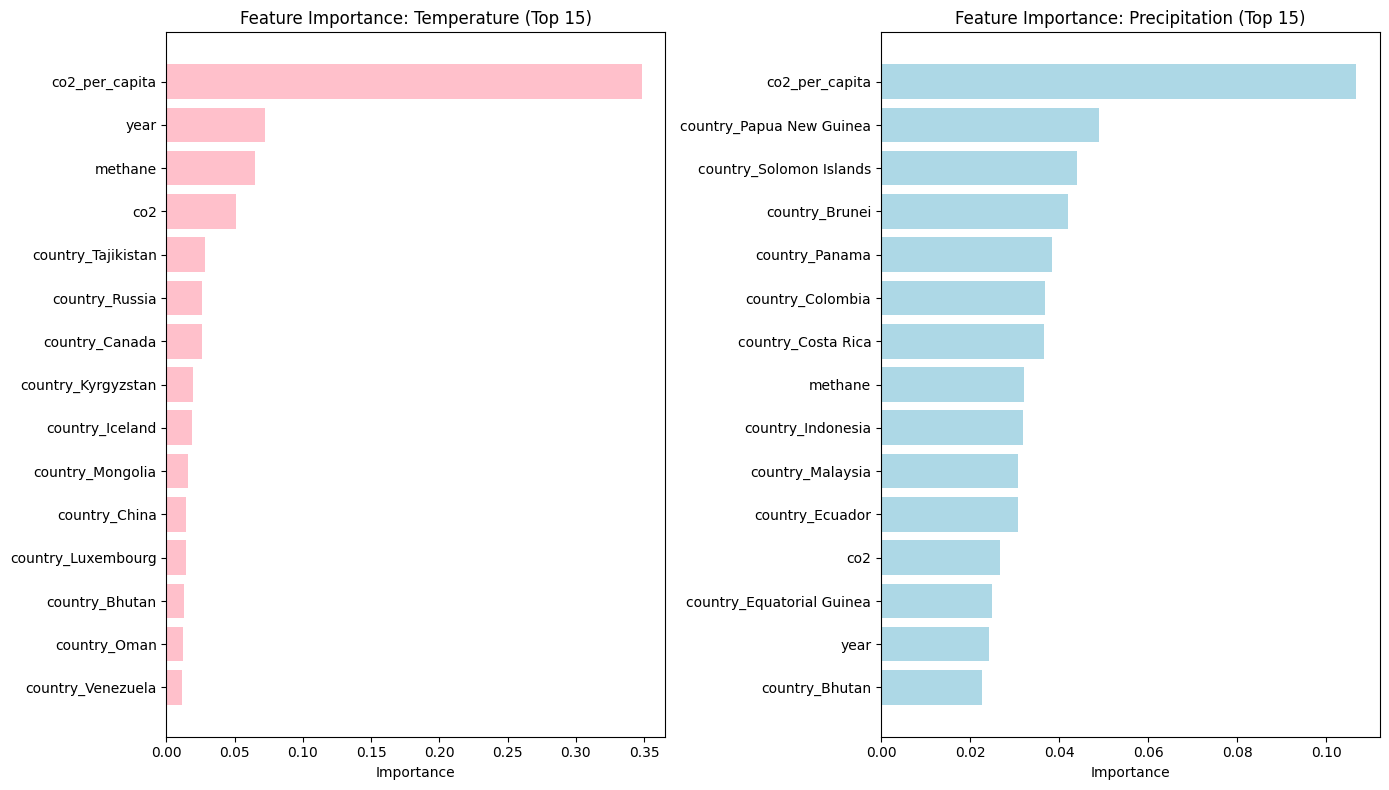

In [37]:
# feature importance

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Top 15 for temperature
temp_importance = pd.Series(rf_temp.feature_importances_, index=X.columns)
top_temp = temp_importance.nlargest(15).sort_values()
axes[0].barh(top_temp.index, top_temp.values, color="pink")
axes[0].set_title("Feature Importance: Temperature (Top 15)")
axes[0].set_xlabel("Importance")

# Top 15 for precipitation
precip_importance = pd.Series(rf_precip.feature_importances_, index=X.columns)
top_precip = precip_importance.nlargest(15).sort_values()
axes[1].barh(top_precip.index, top_precip.values, color="lightblue")
axes[1].set_title("Feature Importance: Precipitation (Top 15)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

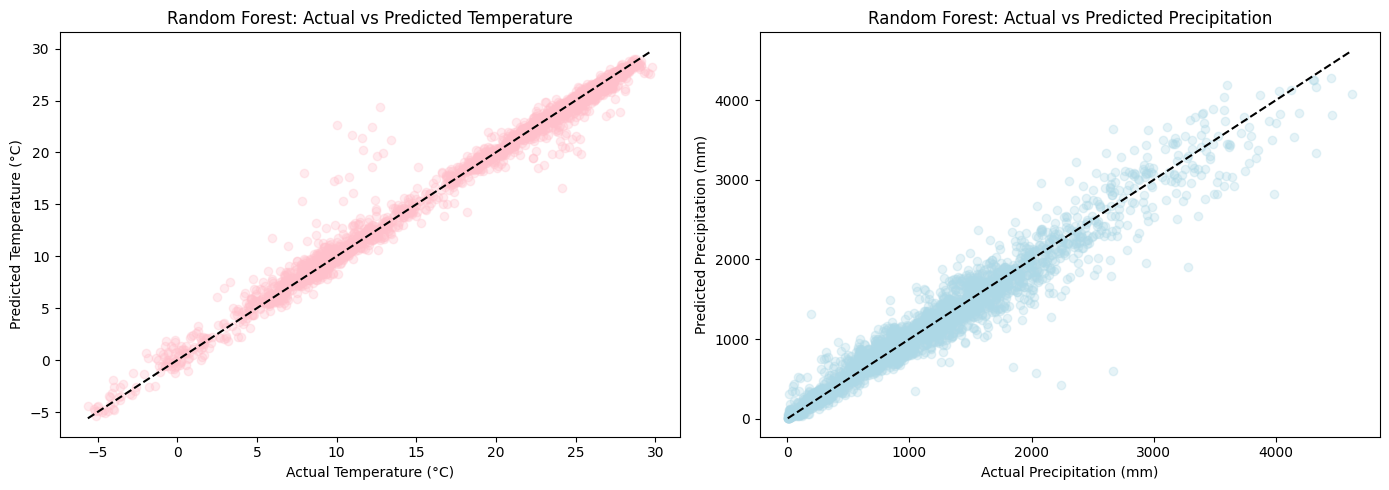

In [38]:
# actual vs predicted scatter for random forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_temp, y_pred_rf_temp, alpha=0.3, color="pink")
axes[0].plot([y_test_temp.min(), y_test_temp.max()], [y_test_temp.min(), y_test_temp.max()], color="black", linestyle="--")
axes[0].set_title("Random Forest: Actual vs Predicted Temperature")
axes[0].set_xlabel("Actual Temperature (°C)")
axes[0].set_ylabel("Predicted Temperature (°C)")

axes[1].scatter(y_test_precip, y_pred_rf_precip, alpha=0.3, color="lightblue")
axes[1].plot([y_test_precip.min(), y_test_precip.max()], [y_test_precip.min(), y_test_precip.max()], color="black", linestyle="--")
axes[1].set_title("Random Forest: Actual vs Predicted Precipitation")
axes[1].set_xlabel("Actual Precipitation (mm)")
axes[1].set_ylabel("Predicted Precipitation (mm)")

plt.tight_layout()
plt.show()